First 5 rows:
   water_temperature  water_clarity  hours_since_last_feed  fish_activity  \
0              22.09          63.45                  29.87           7.73   
1              22.09          62.72                   2.86           4.45   
2              26.11          58.80                  15.28           6.47   
3              28.81          81.75                   3.88           6.53   
4                NaN          80.37                  29.75           5.21   

   ammonia_level  nitrate_level  light_level  fish_hungry  
0           1.11          19.57        57.19            1  
1           1.83          25.21        58.18            0  
2           1.11            NaN        66.81            1  
3           0.25          28.02        59.44            0  
4           0.16          10.10        38.01            1  

Model Performance:
Accuracy: 0.875
F1 Score: 0.8780487804878049

Predicted Fact:
{'fish_hungry': False, 'confidence': np.float64(0.024)}

Final Decision: Do Not F

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


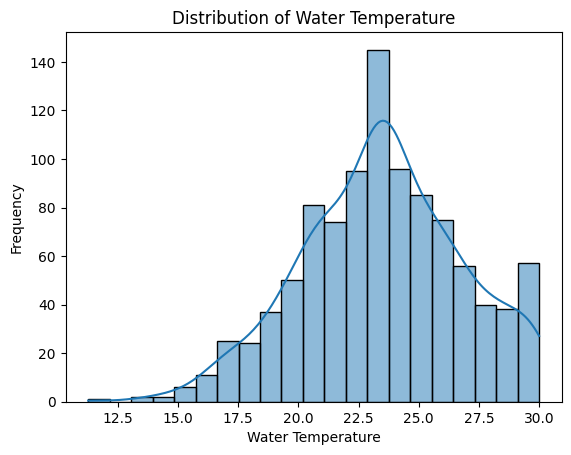

Explanation:
This plot shows how water temperature values are distributed across the dataset.
It is useful for identifying patterns such as concentration of values or possible outliers.



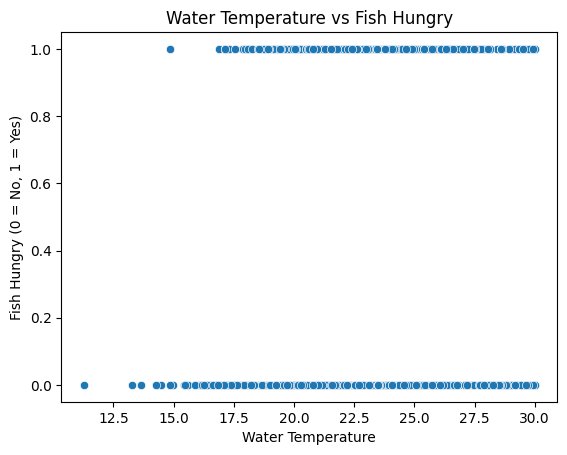

Explanation:
This plot shows the relationship between water temperature and whether the fish is hungry.
It helps to understand if temperature has an effect on feeding behavior.



In [14]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# ==============================
# 2. LOAD DATASET
# ==============================

df = pd.read_csv("/content/ml_dataset.csv")

print("First 5 rows:")
print(df.head())

# ==============================
# 3. DATA CLEANING
# ==============================

# Step 1: Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Step 2: Encode categorical variables (if any)
df = pd.get_dummies(df, drop_first=True)

# ==============================
# 4. SPLIT FEATURES & TARGET
# ==============================
X = df.drop('fish_hungry', axis=1)
y = df['fish_hungry']

# ==============================
# 5. FEATURE SCALING
# ==============================
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 6. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ==============================
# 7. TRAIN MODEL (Logistic Regression)
# ==============================
model = LogisticRegression()
model.fit(X_train, y_train)

# ==============================
# 8. MODEL EVALUATION
# ==============================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Performance:")
print("Accuracy:", accuracy)
print("F1 Score:", f1)

# ==============================
# 9. PREDICT NEW DATA (NO fish_hungry!)
# ==============================
# Example input (CHANGE VALUES if needed)
new_data = [[
    25,    # temperature
    0.7,   # clarity
    5,     # time_since_feed
    0.8,   # activity
    0.2,   # ammonia
    0.3,   # nitrate
    1      # lighting
]]

# Apply same scaling
new_data_scaled = scaler.transform(new_data)

# Prediction + probability
prediction = model.predict(new_data_scaled)[0]
probability = model.predict_proba(new_data_scaled)[0][1]

# ==============================
# 10. CONVERT TO FACT + CONFIDENCE
# ==============================
fish_hungry = True if prediction == 1 else False

fact = {
    "fish_hungry": fish_hungry,
    "confidence": round(probability, 3)
}

print("\nPredicted Fact:")
print(fact)

# ==============================
# 11. SIMPLE RULE-BASED SYSTEM (Integration)
# ==============================
def rule_based_system(fact):
    if fact["fish_hungry"] and fact["confidence"] > 0.7:
        return "Feed"
    else:
        return "Do Not Feed"

decision = rule_based_system(fact)

print("\nFinal Decision:", decision)




# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd

# ==============================
# 2. LOAD DATASETS
# ==============================
rules_df = pd.read_csv("/content/generated_rules.csv")
fish_df = pd.read_csv("/content/ml_dataset.csv")

print("=== RULES DATASET ===")
print(rules_df)

print("\n=== FISH DATA (FIRST ROW) ===")
print(fish_df.head(1))

# ==============================
# 3. CREATE INITIAL FACTS
# ==============================
facts = {}

row = fish_df.iloc[0]

print("\n=== INITIAL FACTS ===")
for col, val in row.items():
    if col == "fish_hungry":
        continue  # must come from ML later

    if pd.notna(val):
        facts[col] = 1.0
        print(f"{col} = {val} (confidence = 1.0)")

# ==============================
# 4. ADD ML PREDICTION
# ==============================
facts["fish_hungry"] = 0.8  # example

print("\n=== ML FACT ADDED ===")
print("fish_hungry = True (confidence = 0.8)")

# ==============================
# 5. CONFIDENCE COMBINATION
# ==============================
def combine_confidence(a, b):
    return a + b - (a * b)

# ==============================
# 6. FORWARD CHAINING (FIXED)
# ==============================
print("\n=== FORWARD CHAINING START ===")

applied_rules = set()  # prevent infinite loops
iteration = 1

while True:
    print(f"\n--- Iteration {iteration} ---")
    new_fact_added = False

    for idx, rule in rules_df.iterrows():
        rule_id = rule["Rule_ID"]

        # Skip already applied rules (optional but safe)
        if rule_id in applied_rules:
            continue

        premises = [p.strip() for p in rule["Premises"].split(",")]
        conclusion = rule["Conclusion"]
        rule_conf = rule["Confidence"]

        # Check if all premises exist
        if all(p in facts for p in premises):

            # Compute confidence
            c_premises = min([facts[p] for p in premises])
            c_infer = rule_conf * c_premises

            print(f"\n✔ Rule Fired: {rule_id}")
            print(f"Premises: {premises}")
            print(f"Conclusion: {conclusion}")
            print(f"c_premises = {c_premises}")
            print(f"c_infer = {c_infer}")

            # Add or update fact
            if conclusion in facts:
                old = facts[conclusion]
                new = combine_confidence(old, c_infer)
                facts[conclusion] = new

                print(f"Updated {conclusion}: {old} → {new}")
            else:
                facts[conclusion] = c_infer
                new_fact_added = True

                print(f"Added NEW fact: {conclusion} = {c_infer}")

            applied_rules.add(rule_id)

    if not new_fact_added:
        print("\nNo new facts added. Stopping.")
        break

    iteration += 1

# ==============================
# 7. FINAL FACTS
# ==============================
print("\n=== FINAL FACTS ===")
for k, v in facts.items():
    print(f"{k}: {round(v, 3)}")

# ==============================
# 8. CHECK R6 & R10 (feed_fish)
# ==============================
print("\n=== RULES R6 & R10 (feed_fish) ===")

feed_conf_list = []

for _, rule in rules_df.iterrows():
    if rule["Conclusion"] == "feed_fish":
        premises = [p.strip() for p in rule["Premises"].split(",")]

        if all(p in facts for p in premises):
            c_premises = min([facts[p] for p in premises])
            c_infer = rule["Confidence"] * c_premises

            print(f"\nRule {rule['Rule_ID']} contributes:")
            print(f"Premises: {premises}")
            print(f"c_infer = {round(c_infer, 3)}")

            feed_conf_list.append(c_infer)

# ==============================
# 9. FINAL COMBINED CONFIDENCE
# ==============================
final_conf = 0

for c in feed_conf_list:
    final_conf = combine_confidence(final_conf, c)

print("\n=== FINAL feed_fish CONFIDENCE ===")
print(f"feed_fish = {round(final_conf, 3)}")

if final_conf > 0.5:
    print("FINAL DECISION: Feed the fish ")
else:
    print("FINAL DECISION: Do NOT feed the fish ")





# ==============================
# PART C: DATA VISUALIZATION
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns

print("\n==============================")
print("PART C: DATA VISUALIZATION")
print("==============================")

# ------------------------------
# 1. SAFETY CHECKS (make code robust)
# ------------------------------

# Ensure fish_hungry is numeric
if df['fish_hungry'].dtype == 'object':
    df['fish_hungry'] = df['fish_hungry'].map({'Feed':1, 'No':0})

# If still not numeric (fallback)
df['fish_hungry'] = df['fish_hungry'].fillna(0)

# ------------------------------
# 2. DISTRIBUTION PLOT
# ------------------------------
plt.figure()
sns.histplot(df['water_temperature'], kde=True)

plt.title("Distribution of Water Temperature")
plt.xlabel("Water Temperature")
plt.ylabel("Frequency")

plt.show()

print("Explanation:")
print("This plot shows how water temperature values are distributed across the dataset.")
print("It is useful for identifying patterns such as concentration of values or possible outliers.\n")

# ------------------------------
# 3. RELATIONSHIP PLOT
# ------------------------------
plt.figure()
sns.scatterplot(x=df['water_temperature'], y=df['fish_hungry'])

plt.title("Water Temperature vs Fish Hungry")
plt.xlabel("Water Temperature")
plt.ylabel("Fish Hungry (0 = No, 1 = Yes)")

plt.show()

print("Explanation:")
print("This plot shows the relationship between water temperature and whether the fish is hungry.")
print("It helps to understand if temperature has an effect on feeding behavior.\n")



